In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [4]:
df = pd.read_parquet("./scaled_emotion_dataset.parquet")  

ID_COLUMN = "comment_id"
TEXT_COLUMN = "comment_text"
OUTPUT_DIR = "pca_analysis"

emotion_columns = [
    col for col in df.columns
    if col not in [ID_COLUMN, TEXT_COLUMN]
]
X_scaled = df[emotion_columns]

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [6]:
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(emotion_columns))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained_variance)

explained_variance.to_csv(
    os.path.join(OUTPUT_DIR, "pca_explained_variance.csv"),
    index=False
)

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.105410,0.105410
1,PC2,0.073253,0.178663
2,PC3,0.067014,0.245676
3,PC4,0.062758,0.308434
4,PC5,0.057954,0.366388
5,PC6,0.052761,0.419149
6,PC7,0.046745,0.465894
7,PC8,0.043722,0.509616
8,PC9,0.040273,0.549889
9,PC10,0.037953,0.587842


Scree Plot

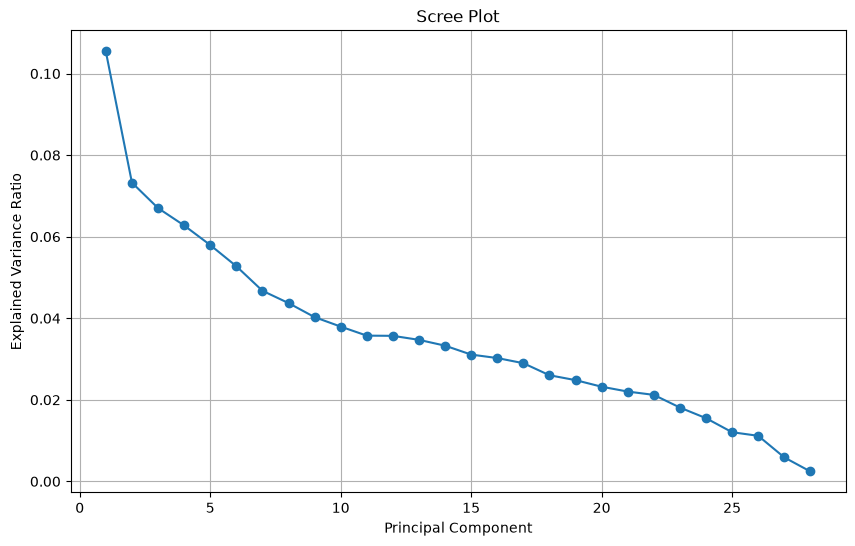

In [7]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(emotion_columns)+1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.savefig(
    os.path.join(OUTPUT_DIR, "pca_scree_plot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cumulative Variance Plot

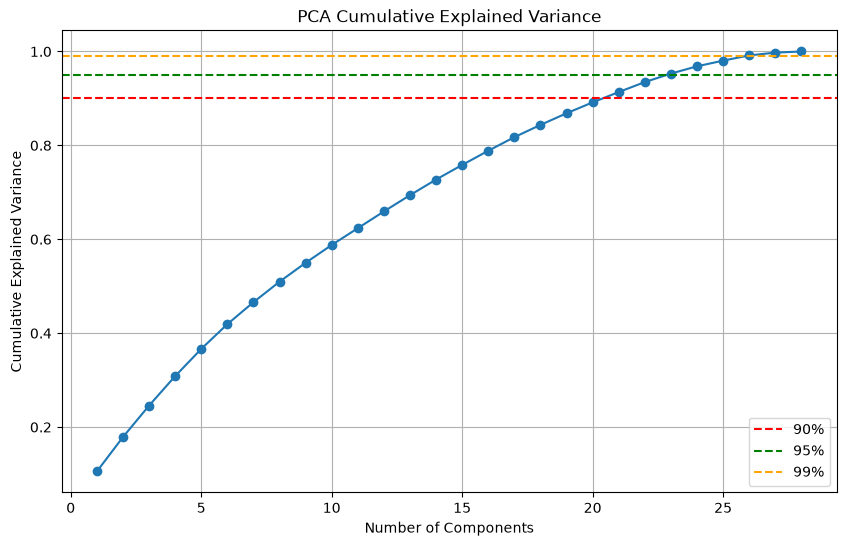

In [8]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(emotion_columns)+1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.axhline(0.95, color="green", linestyle="--", label="95%")
plt.axhline(0.99, color="orange", linestyle="--", label="99%")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Cumulative Explained Variance")

plt.legend()

plt.grid(True)

plt.savefig(
    os.path.join(OUTPUT_DIR, "pca_cumulative_variance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of Components Required

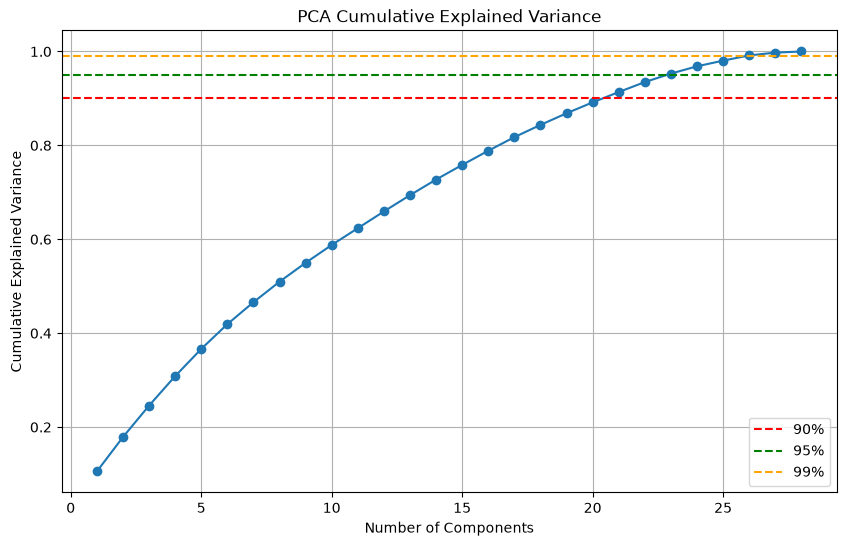

In [9]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(emotion_columns)+1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.axhline(0.95, color="green", linestyle="--", label="95%")
plt.axhline(0.99, color="orange", linestyle="--", label="99%")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Cumulative Explained Variance")

plt.legend()

plt.grid(True)

plt.savefig(
    os.path.join(OUTPUT_DIR, "pca_cumulative_variance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PCA 2D Scatter Plot

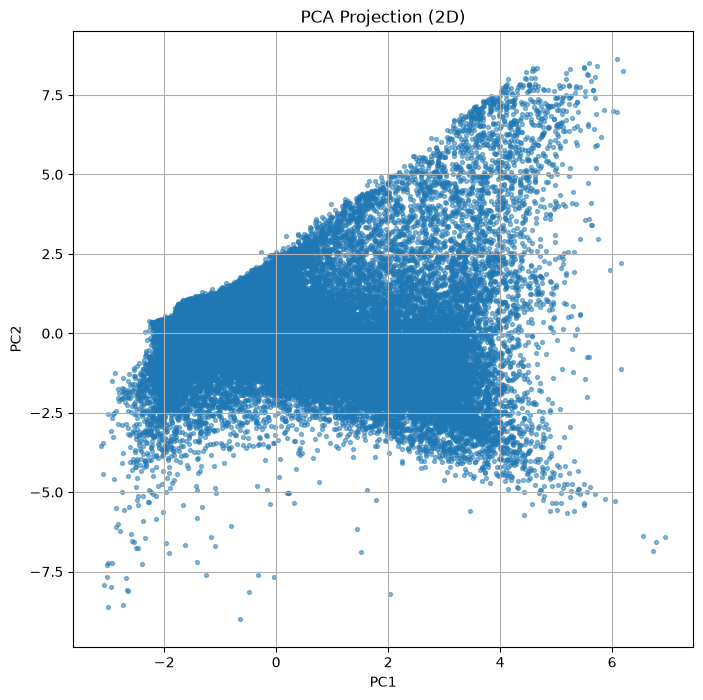

In [10]:
plt.figure(figsize=(8,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=8,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Projection (2D)")

plt.grid(True)

plt.savefig(
    os.path.join(OUTPUT_DIR, "pca_2d.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PCA 3D Plot

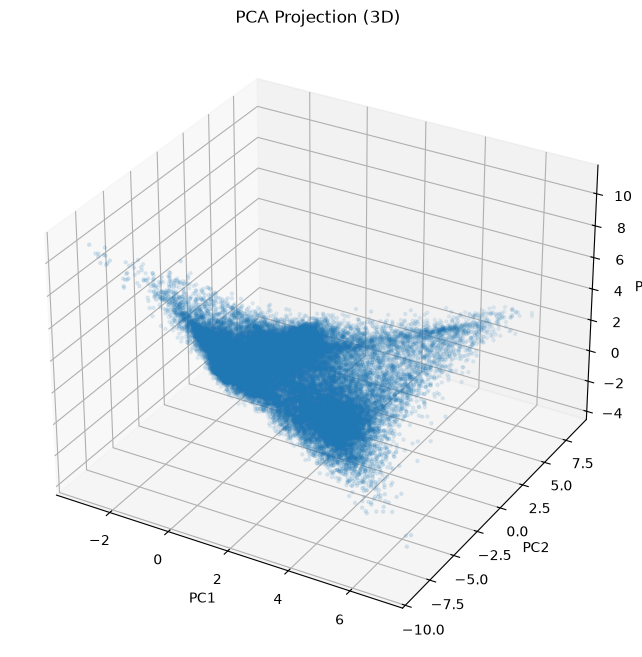

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    s=5,
    alpha=0.4
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("PCA Projection (3D)")

plt.savefig(
    os.path.join(OUTPUT_DIR, "pca_3d.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PCA Loadings

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(emotion_columns))],
    index=emotion_columns
)

display(loadings)

loadings.to_csv(
    os.path.join(OUTPUT_DIR, "pca_loadings.csv")
)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
admiration,-0.223367,-0.014001,-0.075308,-0.022479,0.402090,0.039604,-0.047591,-0.114595,0.165931,-0.208277,...,-0.004746,-0.277351,-0.351754,-0.009323,-0.099251,0.202022,0.039254,-0.024297,0.181450,0.265502
amusement,-0.019594,0.044663,0.044187,0.005107,0.072038,-0.053585,0.031691,0.101529,-0.150688,0.712634,...,-0.087467,0.121269,-0.015609,0.004481,-0.000672,0.088882,-0.030583,0.006727,0.083205,0.094109
anger,0.193893,0.333600,0.043171,-0.240354,0.117951,0.166189,0.082704,0.115094,-0.095021,-0.144716,...,-0.117436,-0.051950,0.076794,0.014571,-0.254518,-0.087171,-0.428126,0.228027,0.116650,0.046624
annoyance,0.277108,0.408761,0.094853,-0.285467,0.071479,0.100780,0.055991,0.030752,-0.022209,-0.040213,...,-0.072461,0.014384,0.012008,-0.017571,0.233693,0.100552,0.620696,-0.364627,-0.091827,0.103977
approval,-0.216553,0.019952,0.038720,-0.172026,-0.323527,0.017934,-0.178653,-0.034851,0.036396,-0.147579,...,-0.086084,0.206318,0.401694,0.001127,-0.009896,-0.091505,0.066287,0.044362,0.139541,0.176288
caring,-0.124601,-0.084045,-0.119651,-0.142803,-0.329985,0.293315,0.313212,-0.091756,-0.050740,-0.122526,...,-0.358936,-0.038499,-0.390630,0.077054,0.106760,-0.197872,0.040189,0.070152,0.120131,0.238894
confusion,0.057888,0.145610,0.120820,0.240954,-0.039355,-0.347105,0.369861,-0.266956,-0.186781,-0.082550,...,0.008945,0.072350,0.001861,0.688676,-0.047923,0.045469,0.017144,0.013967,0.035768,0.067033
curiosity,0.014606,0.123255,0.070222,0.281699,-0.033664,-0.362477,0.418617,-0.106349,-0.192275,-0.174811,...,0.013796,0.019540,-0.010737,-0.659656,-0.020180,-0.030364,0.029867,-0.002794,0.097117,0.120032
desire,0.002463,-0.044338,-0.162088,-0.013854,-0.084329,0.113693,0.250244,0.164319,0.190887,0.256475,...,-0.281286,-0.054861,-0.113591,0.032214,0.007003,-0.008936,-0.003287,0.011531,-0.001271,0.102896
disappointment,0.424610,-0.026648,-0.106007,-0.127830,-0.001066,-0.134886,-0.045166,0.008121,0.043413,-0.012410,...,0.002448,0.052349,-0.045452,-0.070865,0.595446,0.073348,-0.225204,0.215428,0.372395,0.042332


Top Contributing Emotions

In [13]:
for pc in ["PC1", "PC2", "PC3"]:

    print("="*70)
    print(pc)
    print("="*70)

    display(
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

PC1


disappointment    0.424610
sadness           0.416703
grief             0.376604
annoyance         0.277108
admiration        0.223367
approval          0.216553
disgust           0.214580
embarrassment     0.198437
anger             0.193893
remorse           0.176000
Name: PC1, dtype: float64

PC2


annoyance      0.408761
grief          0.400196
anger          0.333600
sadness        0.307233
disgust        0.280373
relief         0.262330
disapproval    0.248189
remorse        0.222257
neutral        0.216834
pride          0.187990
Name: PC2, dtype: float64

PC3


nervousness      0.399908
fear             0.371528
relief           0.369914
realization      0.303847
sadness          0.251303
excitement       0.250573
pride            0.233399
joy              0.232118
embarrassment    0.186575
surprise         0.176988
Name: PC3, dtype: float64